In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import unyt as u

import dev
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import richio


In [2]:
REPO = Path("/home/hey4/rich_tde")
DATA_ROOT = REPO / "data/processed/RegionalCircularization"
FIGURE_DIR = DATA_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SS24_REFERENCE = REPO / "data/processed/SS24-circularization-t/SS24-Figure2-chi-vector-extracted.txt"

configs = {
    "1e4": {"Mbh": 1e4, "Mstar": 0.5, "Rstar": 0.47, "color": "C0", "label": r"$10^4\,M_\odot$"},
    "1e5": {"Mbh": 1e5, "Mstar": 0.5, "Rstar": 0.47, "color": "C1", "label": r"$10^5\,M_\odot$"},
    "1e6": {"Mbh": 1e6, "Mstar": 1.0, "Rstar": 1.0, "color": "C2", "label": r"$10^6\,M_\odot$"},
}
for run, cfg in configs.items():
    Mbh = cfg["Mbh"] * richio.units.mscale
    Mstar = cfg["Mstar"] * richio.units.mscale
    Rstar = cfg["Rstar"] * richio.units.lscale
    cfg["tmin_day"] = (
        np.pi / np.sqrt(2)
        * (Rstar**3 / u.G / Mstar) ** 0.5
        * (Mbh / Mstar) ** 0.5
    ).to_value("day")
    cfg["bs21"] = (Mstar / Mbh).to_value() ** (2 / 3)

regions = ["Pericenter side", "Outgoing stream", "Incoming stream", "Beyond apocenter"]
region_styles = ["-", ":", "--", "-."]
region_colors = ["C3", "C0", "C2", "0.55"]
print({run: {"tmin_day": cfg["tmin_day"], "BS21_nozzle_ratio": cfg["bs21"]} for run, cfg in configs.items()})


{'1e4': {'tmin_day': 2.656037932057755, 'BS21_nozzle_ratio': 0.0013572088082974539}, '1e5': {'tmin_day': 8.399129417106058, 'BS21_nozzle_ratio': 0.00029240177382128675}, '1e6': {'tmin_day': 41.21520748698829, 'BS21_nozzle_ratio': 0.00010000000000000005}}


In [3]:
def load_regional_chi(run):
    path = DATA_ROOT / run / f"regional-chi-{run}.txt"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}; run the regional normalization job first")
    raw = np.atleast_2d(np.loadtxt(path))
    if raw.shape[1] != 16:
        raise ValueError(f"{path} has {raw.shape[1]} columns; expected 16")
    if np.isinf(raw).any():
        raise ValueError(f"{path} contains infinity")
    required = raw[:, [0, 1, 2, 3, 6, 7, 8, 9]]
    if not np.isfinite(required).all():
        raise ValueError(f"{path} has NaN in a required time or power column")
    if not np.array_equal(raw[:, 0], raw[:, 0].astype(int)):
        raise ValueError(f"{path} has a non-integer snapshot number")
    if len(np.unique(raw[:, 0])) != len(raw) or np.any(np.diff(raw[:, 2]) <= 0):
        raise ValueError(f"{path} has duplicate snapshots or non-increasing time")

    late_support = np.isfinite(raw[:, 5]) & (raw[:, 5] > 0)
    early_support = np.isfinite(raw[:, 4]) & (raw[:, 4] > 0)
    if not np.array_equal(np.isfinite(raw[:, 10:15]).all(axis=1), late_support):
        raise ValueError(f"{path} has an inconsistent late-fallback NaN mask")
    if not np.array_equal(np.isfinite(raw[:, 15]), early_support):
        raise ValueError(f"{path} has an inconsistent early-fallback NaN mask")
    if not np.allclose(raw[late_support, 14], raw[late_support, 10:14].sum(axis=1), rtol=2e-12, atol=0):
        raise ValueError(f"{path} regional efficiencies are not additive")
    return raw

data = {run: load_regional_chi(run) for run in configs}
reference = np.atleast_2d(np.loadtxt(SS24_REFERENCE))
if reference.shape[1] != 2 or not np.isfinite(reference).all():
    raise ValueError("Invalid SS24 vector reference")
for run, raw in data.items():
    valid = np.isfinite(raw[:, 14])
    post = valid & (raw[:, 3] >= 1)
    valid_range = (raw[valid, 3].min(), raw[valid, 3].max()) if valid.any() else (np.nan, np.nan)
    print(f"{run}: {len(raw)} unique rows; finite chi {valid.sum()}; support {valid_range[0]:.3f}--{valid_range[1]:.3f} t_fb; post-fallback rows {post.sum()}")


1e4: 152 unique rows; finite chi 110; support 0.265--2.175 t_fb; post-fallback rows 74
1e5: 162 unique rows; finite chi 66; support 0.258--0.606 t_fb; post-fallback rows 0
1e6: 822 unique rows; finite chi 361; support 0.360--1.491 t_fb; post-fallback rows 137


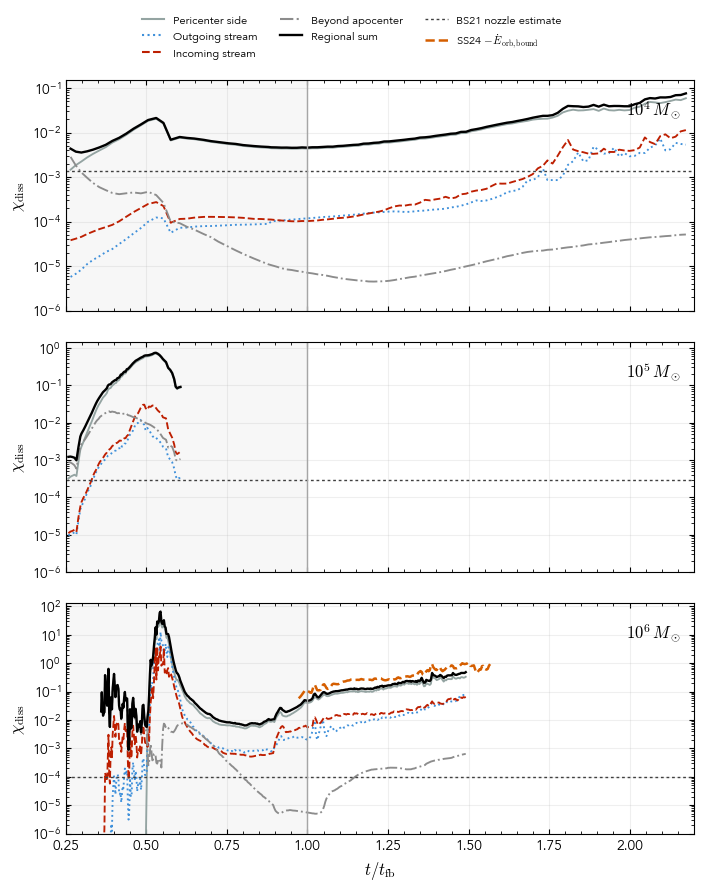

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(7.2, 9.0), sharex=True)
for ax, (run, cfg) in zip(axes, configs.items()):
    raw = data[run]
    tau = raw[:, 3]
    valid = np.isfinite(raw[:, 14]) & (tau >= 0.25)
    for index, (label, style, color) in enumerate(zip(regions, region_styles, region_colors)):
        positive = valid & (raw[:, 10 + index] > 0)
        ax.plot(tau[positive], raw[positive, 10 + index], ls=style, color=color, lw=1.35, label=label)
    total_positive = valid & (raw[:, 14] > 0)
    ax.plot(tau[total_positive], raw[total_positive, 14], color="k", lw=1.7, label="Regional sum")
    ax.axhline(cfg["bs21"], color="0.25", lw=1, ls=(0, (2, 2)), label="BS21 nozzle estimate")
    ax.axvspan(0.25, 1, color="0.75", alpha=0.12)
    ax.axvline(1, color="0.65", lw=1)
    ax.text(0.98, 0.92, cfg["label"], transform=ax.transAxes, ha="right", va="top")
    ax.set_yscale("log")
    ax.set_ylim(1e-6, 2 * np.nanmax(raw[total_positive, 14]))
    ax.set_ylabel(r"$\chi_{\rm diss}$")
    ax.grid(alpha=0.2)

tau_reference = reference[:, 0] / configs["1e6"]["tmin_day"]
axes[-1].plot(tau_reference, reference[:, 1], color="#D55E00", lw=1.8, ls="--", label=r"SS24 $-\dot E_{\rm orb,bound}$")
axes[-1].set_xlabel(r"$t/t_{\rm fb}$")
axes[-1].set_xlim(0.25, 2.2)
legend_handles = [Line2D([], [], color=c, ls=s, lw=1.5, label=l) for l, s, c in zip(regions, region_styles, region_colors)]
legend_handles += [
    Line2D([], [], color="k", lw=1.7, label="Regional sum"),
    Line2D([], [], color="0.25", lw=1, ls=(0, (2, 2)), label="BS21 nozzle estimate"),
    Line2D([], [], color="#D55E00", lw=1.8, ls="--", label=r"SS24 $-\dot E_{\rm orb,bound}$"),
]
fig.legend(handles=legend_handles, frameon=False, fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 0.995))
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURE_DIR / "regional-chi-1e4-1e5-1e6.png", dpi=220, bbox_inches="tight")
plt.show()


1e4: early/late normalization over all support gives median |Delta chi|/chi = 11.82%
1e4: post-fallback median |Delta chi|/chi = 8.00%
1e5: early/late normalization over all support gives median |Delta chi|/chi = 124.05%
1e5: no post-fallback early/late comparison
1e6: early/late normalization over all support gives median |Delta chi|/chi = 46.28%
1e6: post-fallback median |Delta chi|/chi = 19.38%


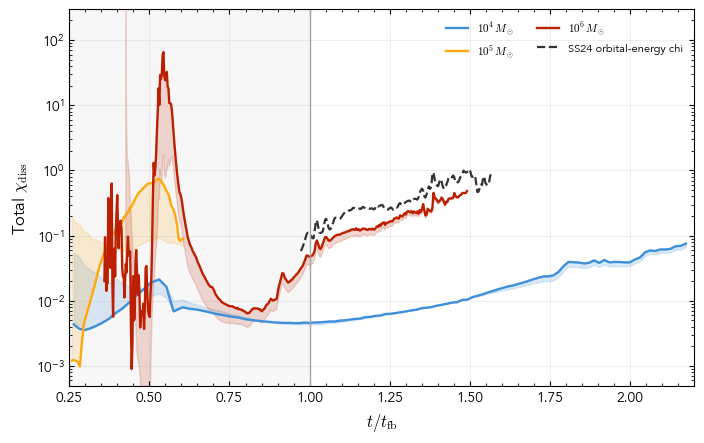

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for run, cfg in configs.items():
    raw = data[run]
    tau = raw[:, 3]
    late = raw[:, 14]
    early = raw[:, 15]
    valid_late = np.isfinite(late) & (late > 0) & (tau >= 0.25)
    ax.plot(tau[valid_late], late[valid_late], color=cfg["color"], lw=1.7, label=cfg["label"])
    common = valid_late & np.isfinite(early) & (early > 0)
    if common.any():
        ax.fill_between(tau[common], np.minimum(late[common], early[common]), np.maximum(late[common], early[common]), color=cfg["color"], alpha=0.18)
        frac = np.abs(late[common] / early[common] - 1)
        print(f"{run}: early/late normalization over all support gives median |Delta chi|/chi = {np.median(frac):.2%}")
        post_common = common & (tau >= 1)
        if post_common.any():
            post_frac = np.abs(late[post_common] / early[post_common] - 1)
            print(f"{run}: post-fallback median |Delta chi|/chi = {np.median(post_frac):.2%}")
        else:
            print(f"{run}: no post-fallback early/late comparison")
ax.plot(tau_reference, reference[:, 1], color="0.2", lw=1.6, ls="--", label="SS24 orbital-energy chi")
ax.axvspan(0.25, 1, color="0.75", alpha=0.12)
ax.axvline(1, color="0.65", lw=1)
ax.set_xlim(0.25, 2.2)
ax.set_yscale("log")
ax.set_ylim(5e-4, 3e2)
ax.set_xlabel(r"$t/t_{\rm fb}$")
ax.set_ylabel(r"Total $\chi_{\rm diss}$")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "regional-chi-total-fallback-sensitivity.png", dpi=220, bbox_inches="tight")
plt.show()


1e4: post-fallback median chi_pericenter / BS21 = 10.5; range 3.26--43.4
1e5: no post-fallback coverage; BS21 rate comparison is not available
1e6: post-fallback median chi_pericenter / BS21 = 1.31e+03; range 397--3.68e+03


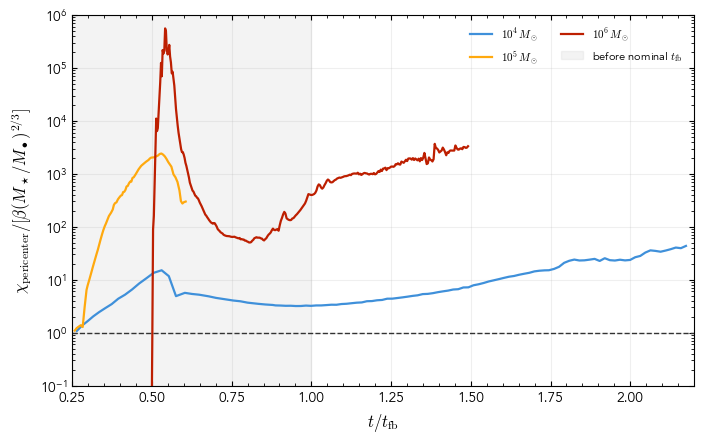

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for run, cfg in configs.items():
    raw = data[run]
    tau = raw[:, 3]
    ratio = raw[:, 10] / cfg["bs21"]
    valid = np.isfinite(ratio) & (ratio > 0) & (tau >= 0.25)
    ax.plot(tau[valid], ratio[valid], color=cfg["color"], lw=1.6, label=cfg["label"])
    post = valid & (tau >= 1)
    if post.any():
        print(f"{run}: post-fallback median chi_pericenter / BS21 = {np.median(ratio[post]):.3g}; range {ratio[post].min():.3g}--{ratio[post].max():.3g}")
    else:
        print(f"{run}: no post-fallback coverage; BS21 rate comparison is not available")
ax.axhline(1, color="0.2", ls="--", lw=1)
ax.axvspan(0.25, 1, color="0.7", alpha=0.15, label=r"before nominal $t_{\rm fb}$")
ax.set_xlim(0.25, 2.2)
ax.set_yscale("log")
ax.set_ylim(1e-1, 1e6)
ax.set_xlabel(r"$t/t_{\rm fb}$")
ax.set_ylabel(r"$\chi_{\rm pericenter}/[\beta(M_\star/M_\bullet)^{2/3}]$")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "regional-chi-pericenter-vs-BS21.png", dpi=220, bbox_inches="tight")
plt.show()


In [7]:
for run, cfg in configs.items():
    raw = data[run]
    post = np.isfinite(raw[:, 14]) & (raw[:, 3] >= 1)
    if not post.any():
        print(f"{run}: no post-fallback regional summary")
        continue
    medians = np.median(raw[post, 10:14], axis=0)
    fractions = np.median(raw[post, 10:14] / raw[post, 14, None], axis=0)
    print(f"{run}: post-fallback median total chi = {np.median(raw[post, 14]):.4g}")
    print("  median regional chi:", dict(zip(regions, medians)))
    print("  median regional fraction:", dict(zip(regions, fractions)))

raw = data["1e6"]
tau = raw[:, 3]
reference_tau = reference[:, 0] / configs["1e6"]["tmin_day"]
compare = np.isfinite(raw[:, 14]) & (tau >= max(1, reference_tau.min())) & (tau <= reference_tau.max())
reference_on_grid = np.interp(tau[compare], reference_tau, reference[:, 1])
ratio_to_ss24 = raw[compare, 14] / reference_on_grid
print(f"1e6: regional shock-sum / SS24 orbital-energy chi median = {np.median(ratio_to_ss24):.3f}; range {ratio_to_ss24.min():.3f}--{ratio_to_ss24.max():.3f}")


1e4: post-fallback median total chi = 0.01539
  median regional chi: {'Pericenter side': np.float64(0.014288251267865325), 'Outgoing stream': np.float64(0.0003721363941646611), 'Incoming stream': np.float64(0.0007111400463631196), 'Beyond apocenter': np.float64(1.49690723925215e-05)}
  median regional fraction: {'Pericenter side': np.float64(0.9289851017586911), 'Outgoing stream': np.float64(0.027350009569376832), 'Incoming stream': np.float64(0.04464834921381958), 'Beyond apocenter': np.float64(0.0008853425048724981)}
1e5: no post-fallback regional summary
1e6: post-fallback median total chi = 0.1604
  median regional chi: {'Pericenter side': np.float64(0.13110518783442354), 'Outgoing stream': np.float64(0.012101923199279054), 'Incoming stream': np.float64(0.01735707459387141), 'Beyond apocenter': np.float64(0.00018879903279236457)}
  median regional fraction: {'Pericenter side': np.float64(0.8108300363283729), 'Outgoing stream': np.float64(0.07549822335440244), 'Incoming stream': np.

The regional curves use the additive shock-power definition, $\chi_{\rm diss,region}=\dot E_{\rm diss,region}/(\dot M_{\rm fb}\Delta\epsilon_{\rm circ})$. They should not be relabelled as the SS24 orbital-energy derivative. The Bonnerot & Stone (2021) comparison is an order-of-magnitude nozzle test: their one-pass specific loss maps to this rate ratio only if returning material is processed promptly, while the broad $x>0$ region can contain non-nozzle dissipation.